# Module 6 — SHAP Explainability for LSTM Volatility Forecasting

**QuantRisk AI**

This notebook explains the trained Module 5 LSTM using SHAP (SHapley Additive exPlanations). The model is **not retrained**. The analysis uses the saved Module 5 model, training-fitted preprocessing objects, and the same leakage-safe sequence construction.

### Goal
Answer: **Which features and time periods contributed to the LSTM volatility forecast?**

Because the LSTM input has shape `(samples, 60 time steps, 16 features)`, SHAP values are calculated at the time-step/feature level and then aggregated in two ways:
- global importance: mean absolute SHAP across samples and time
- local explanation: signed SHAP contributions aggregated across the 60-day window

## 1. Imports and configuration

In [1]:
import os
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
from torch import nn

RANDOM_STATE = 42
HORIZON = 20
LOOKBACK = 60

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("SHAP:", shap.__version__)
print("PyTorch:", torch.__version__)
print("Device:", device)

SHAP: 0.51.0
PyTorch: 2.14.1+cpu
Device: cpu


## 2. Load Module 3 data and Module 5 artifacts

The model and preprocessing must match the exact Module 5 pipeline. No Module 3 feature calculations are repeated.

In [2]:
DATA_CANDIDATES = [
    "../backend/data/feature_engineered_dataset.csv"
]

MODEL_CANDIDATES = [
    "../backend/models/lstm_volatility_model.pt"
]

PREP_CANDIDATES = [
    "../backend/models/lstm_preprocessing.pkl"
]

def first_existing(paths):
    return next((p for p in paths if os.path.exists(p)), None)

DATA_PATH = first_existing(DATA_CANDIDATES)
MODEL_PATH = first_existing(MODEL_CANDIDATES)
PREP_PATH = first_existing(PREP_CANDIDATES)

if not all([DATA_PATH, MODEL_PATH, PREP_PATH]):
    raise FileNotFoundError(
        "Required Module 5 artifacts not found. Expected the feature dataset, "
        "lstm_volatility_model.pt and lstm_preprocessing.pkl."
    )

df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values(["Stock", "Date"]).reset_index(drop=True)
with open(PREP_PATH, "rb") as f:
    preprocessing = pickle.load(f)

LSTM_FEATURES = list(preprocessing["features"])
LOOKBACK = int(preprocessing["lookback"])
HORIZON = int(preprocessing["horizon"])
risk_threshold = float(preprocessing["risk_threshold"])
imputer = preprocessing["imputer"]
scaler = preprocessing["scaler"]

print("Dataset:", df.shape)
print("Features:", len(LSTM_FEATURES))
print("Lookback:", LOOKBACK)
print("Horizon:", HORIZON)
print("Risk threshold:", f"{risk_threshold:.6f} ({risk_threshold:.2%})")

Dataset: (70764, 37)
Features: 16
Lookback: 60
Horizon: 20
Risk threshold: 0.021286 (2.13%)


## 3. Rebuild the exact Module 5 test sequences

The sequence builder allows a validation/test observation to use historical observations immediately before the evaluation period. The target remains strictly in the target split. Preprocessing is reused from Module 5 and is **not refitted**.

In [3]:
# Recreate the Module 5 masks using the actual market-date index.
TRAIN_END = pd.Timestamp("2023-12-31")
VAL_END = pd.Timestamp("2024-12-31")
TEST_END = pd.Timestamp("2025-12-31")

trading_dates = np.sort(df["Date"].dropna().unique())
date_to_idx = pd.Series(np.arange(len(trading_dates)), index=trading_dates)
df["Market_Day_Index"] = df["Date"].map(date_to_idx)

train_end_idx = int(date_to_idx.loc[TRAIN_END if TRAIN_END in date_to_idx.index else trading_dates[date_to_idx.index <= TRAIN_END][-1]])
val_end_idx = int(date_to_idx.loc[VAL_END if VAL_END in date_to_idx.index else trading_dates[date_to_idx.index <= VAL_END][-1]])

# Future 20-session realized volatility, same definition as Module 5.
def future_volatility(series, horizon=20):
    values = series.to_numpy(dtype=float)
    out = np.full(len(values), np.nan)
    for i in range(len(values) - horizon):
        window = values[i + 1:i + 1 + horizon]
        if np.isfinite(window).all():
            out[i] = np.std(window, ddof=1)
    return pd.Series(out, index=series.index)

df["Future_Volatility_20D"] = (
    df.groupby("Stock", group_keys=False)["Daily_Return"]
      .apply(lambda s: future_volatility(s, HORIZON))
)

train_mask = (df["Date"] <= TRAIN_END) & df["Future_Volatility_20D"].notna() & (df["Market_Day_Index"] <= train_end_idx - HORIZON)
val_mask = (df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END) & df["Future_Volatility_20D"].notna() & (df["Market_Day_Index"] <= val_end_idx - HORIZON)
test_mask = (df["Date"] > VAL_END) & (df["Date"] <= TEST_END) & df["Future_Volatility_20D"].notna()

# IMPORTANT: use Module 5's saved train-fitted preprocessing.
X_all_scaled = scaler.transform(imputer.transform(df[LSTM_FEATURES])).astype(np.float32)

def make_sequences_with_history(df, target_mask, X_scaled, lookback):
    target_indices = np.flatnonzero(target_mask.to_numpy())
    X_list, y_list, meta = [], [], []
    stock_positions = {stock: g.index.to_numpy() for stock, g in df.groupby("Stock", sort=False)}

    for idx in target_indices:
        stock = df.at[idx, "Stock"]
        positions = stock_positions[stock]
        loc = np.searchsorted(positions, idx)
        if loc < lookback - 1:
            continue
        window_positions = positions[loc - lookback + 1:loc + 1]
        window = X_scaled[window_positions]
        if window.shape != (lookback, len(LSTM_FEATURES)) or not np.isfinite(window).all():
            continue
        X_list.append(window)
        y_list.append(float(df.at[idx, "Future_Volatility_20D"]))
        meta.append((df.at[idx, "Date"], stock, idx))

    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(y_list, dtype=np.float32),
            pd.DataFrame(meta, columns=["Date", "Stock", "Global_Index"]))

Xtr, ytr, meta_tr = make_sequences_with_history(df, train_mask, X_all_scaled, LOOKBACK)
Xva, yva, meta_va = make_sequences_with_history(df, val_mask, X_all_scaled, LOOKBACK)
Xte, yte, meta_te = make_sequences_with_history(df, test_mask, X_all_scaled, LOOKBACK)

print("Train:", Xtr.shape)
print("Validation:", Xva.shape)
print("Test:", Xte.shape)
print("Test date range:", meta_te.Date.min(), "to", meta_te.Date.max())

Train: (42834, 60, 16)
Validation: (10976, 60, 16)
Test: (11123, 60, 16)
Test date range: 2025-01-02 00:00:00 to 2025-12-02 00:00:00


## 4. Recreate and load the trained LSTM

In [9]:
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        last_hidden = output[:, -1, :]
        return self.fc(self.dropout(last_hidden))

model = VolatilityLSTM(len(LSTM_FEATURES)).to(device)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

print(model)
print("Model loaded successfully.")

VolatilityLSTM(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Model loaded successfully.


## 5. Select a training-only SHAP background and genuinely stratified explanation sample

SHAP for a recurrent neural network can be computationally expensive. We therefore use a small training-only background and a genuinely stratified test explanation sample. The explanation sample is balanced across the model's prediction quartiles, with four required diagnostic cases added explicitly.

In [10]:
# 5. Select a training-only SHAP background and a genuinely stratified test explanation sample

# Background remains training-only.
rng = np.random.default_rng(RANDOM_STATE)

BACKGROUND_SIZE = min(50, len(Xtr))
EXPLAIN_SIZE = min(100, len(Xte))

bg_idx = rng.choice(len(Xtr), size=BACKGROUND_SIZE, replace=False)
background = torch.from_numpy(Xtr[bg_idx]).to(device)

# First obtain predictions for ALL test sequences.
# This is only used to construct a representative retrospective explanation sample.
with torch.no_grad():
    all_test_pred = (
        model(torch.from_numpy(Xte).to(device))
        .detach().cpu().numpy().reshape(-1)
    )

# Create four equal-sized prediction strata.
# This ensures SHAP explanations cover the model's low -> high prediction range.
prediction_rank = pd.Series(all_test_pred).rank(method="first")
stratum = pd.qcut(
    prediction_rank,
    q=4,
    labels=["Q1_Low", "Q2_LowMid", "Q3_HighMid", "Q4_High"]
)

# Reserve 24 observations from each quartile = 96 observations.
# Four additional slots are reserved for deliberately selected diagnostic cases.
base_per_stratum = min(24, EXPLAIN_SIZE // 4)
base_indices = []

for label in ["Q1_Low", "Q2_LowMid", "Q3_HighMid", "Q4_High"]:
    candidates = np.flatnonzero(stratum.to_numpy() == label)
    take = min(base_per_stratum, len(candidates))
    base_indices.extend(
        rng.choice(candidates, size=take, replace=False).tolist()
    )

# Four required diagnostic cases from the complete test set.
actual_test_pred_error = np.abs(yte - all_test_pred)

special_candidates = {
    "Highest predicted volatility": int(np.argmax(all_test_pred)),
    "Lowest predicted volatility": int(np.argmin(all_test_pred)),
    "Largest prediction error": int(np.argmax(actual_test_pred_error)),
    "Closest to risk threshold": int(
        np.argmin(np.abs(all_test_pred - risk_threshold))
    ),
}

selected = list(dict.fromkeys(base_indices))

# Add the four special cases.
for idx in special_candidates.values():
    if idx not in selected and len(selected) < EXPLAIN_SIZE:
        selected.append(idx)

# Fill any remaining slots randomly from the unused test observations.
if len(selected) < EXPLAIN_SIZE:
    remaining = np.setdiff1d(np.arange(len(Xte)), np.array(selected))
    extra = rng.choice(
        remaining,
        size=EXPLAIN_SIZE - len(selected),
        replace=False
    )
    selected.extend(extra.tolist())

explain_idx = np.array(selected[:EXPLAIN_SIZE], dtype=int)

background = background.to(device)
X_explain = torch.from_numpy(Xte[explain_idx]).to(device)

# Verify the actual selected sample covers all four prediction strata.
selected_strata = stratum.iloc[explain_idx].value_counts().sort_index()

print("Background shape:", tuple(background.shape))
print("Explanation shape:", tuple(X_explain.shape))
print("Selected prediction strata:")
print(selected_strata)
print("Special diagnostic cases:")
for name, idx in special_candidates.items():
    print(
        f"  {name}: index={idx}, "
        f"predicted={all_test_pred[idx]:.6f}, "
        f"actual={yte[idx]:.6f}"
    )

assert len(explain_idx) == EXPLAIN_SIZE
assert len(np.unique(explain_idx)) == EXPLAIN_SIZE
assert all(idx in explain_idx for idx in special_candidates.values())

print("Genuine stratified SHAP sampling: PASS")


Background shape: (50, 60, 16)
Explanation shape: (100, 60, 16)
Selected prediction strata:
Q1_Low        25
Q2_LowMid     24
Q3_HighMid    25
Q4_High       26
Name: count, dtype: int64
Special diagnostic cases:
  Highest predicted volatility: index=3192, predicted=0.034437, actual=0.034338
  Lowest predicted volatility: index=7249, predicted=0.004593, actual=0.009648
  Largest prediction error: index=5265, predicted=0.016624, actual=0.067131
  Closest to risk threshold: index=1843, predicted=0.021291, actual=0.025368
Genuine stratified SHAP sampling: PASS


**Sampling note:** the SHAP sample is selected from the full 2025 test prediction distribution using four prediction quartiles (Q1–Q4). Twenty-four observations are sampled per quartile, and four deliberately selected diagnostic cases are added. This gives broad coverage of model behavior while keeping SHAP computationally manageable.


## 6. Compute SHAP values with GradientExplainer

`GradientExplainer` is used because the forecasting model is a PyTorch LSTM. Each SHAP value has shape `(sample, time step, feature)` and measures the contribution of that input element relative to the background distribution.

In [11]:
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(X_explain)

# SHAP may return a list for single-output models depending on the SHAP version.
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

# Remove a final singleton output dimension if present.
if shap_values.ndim == 4 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]

print("SHAP shape:", shap_values.shape)
assert shap_values.shape == (EXPLAIN_SIZE, LOOKBACK, len(LSTM_FEATURES))
print("SHAP computation successful.")

SHAP shape: (100, 60, 16)
SHAP computation successful.


## 7. Global feature importance

For each feature, average the absolute SHAP value over all explained samples and all 60 time steps. Larger values indicate greater average influence on the LSTM output magnitude. This is an **importance measure**, not a causal effect.

,Feature,Mean_Abs_SHAP
0,High_Low_Pct,0.000051
1,Rolling_Volatility_20D,0.000024
2,Volume_Ratio,0.000015
3,Volume_Change,0.000011
4,Volatility_Ratio,0.000011
5,Price_MA50_Ratio,0.000010
6,Rolling_Volatility_60D,0.000009
7,ATR_14,0.000008
8,Momentum_20D,0.000008
9,MACD,0.000008


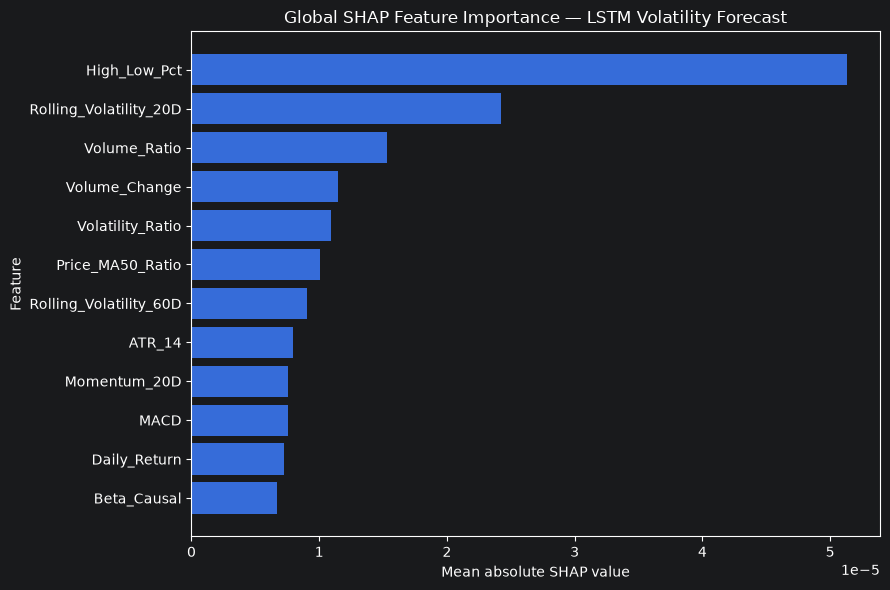

In [12]:
global_importance = pd.DataFrame({
    "Feature": LSTM_FEATURES,
    "Mean_Abs_SHAP": np.mean(np.abs(shap_values), axis=(0, 1))
}).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

display(global_importance.round(6))

plt.figure(figsize=(9, 6))
top = global_importance.head(12).sort_values("Mean_Abs_SHAP")
plt.barh(top["Feature"], top["Mean_Abs_SHAP"])
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance — LSTM Volatility Forecast")
plt.tight_layout()
plt.show()

## 8. Feature contribution direction

Signed SHAP values are aggregated across the 60-day window. Positive values push the forecast upward; negative values push it downward for the explained observation.

,Feature,Mean_Signed_SHAP
14,High_Low_Pct,-0.000024
1,Rolling_Volatility_20D,-0.000011
2,Rolling_Volatility_60D,-0.000005
4,Price_MA50_Ratio,-0.000002
13,Volume_Change,-0.000001
7,MACD,-0.000001
8,MACD_Histogram,-0.000001
12,Volume_Ratio,-0.000001
15,Gap_Pct,-0.000001
3,Price_MA20_Ratio,0.000000


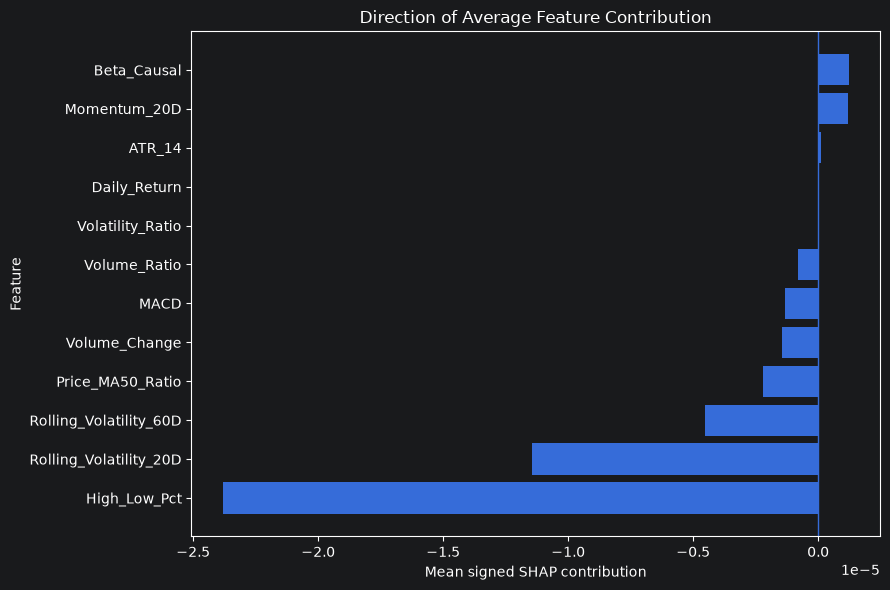

In [13]:
mean_signed = pd.DataFrame({
    "Feature": LSTM_FEATURES,
    "Mean_Signed_SHAP": np.mean(shap_values, axis=(0, 1))
}).sort_values("Mean_Signed_SHAP")

display(mean_signed.round(6))

plt.figure(figsize=(9, 6))
top_abs = global_importance.head(12)["Feature"]
plot_df = mean_signed[mean_signed["Feature"].isin(top_abs)].sort_values("Mean_Signed_SHAP")
plt.barh(plot_df["Feature"], plot_df["Mean_Signed_SHAP"])
plt.axvline(0, linewidth=1)
plt.xlabel("Mean signed SHAP contribution")
plt.ylabel("Feature")
plt.title("Direction of Average Feature Contribution")
plt.tight_layout()
plt.show()

## 9. Temporal importance — which part of the 60-day history matters?

The LSTM receives 60 observations. We aggregate absolute SHAP values across features to measure how influential each historical time step is.

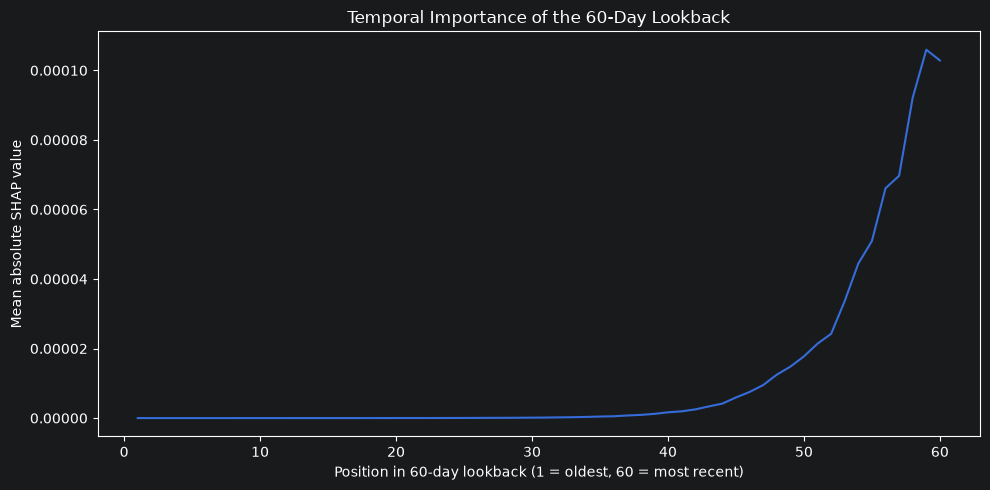

Most influential lookback position: 59
Most recent position importance: 0.00010286008407671146


In [14]:
time_importance = np.mean(np.abs(shap_values), axis=(0, 2))

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, LOOKBACK + 1), time_importance)
plt.xlabel("Position in 60-day lookback (1 = oldest, 60 = most recent)")
plt.ylabel("Mean absolute SHAP value")
plt.title("Temporal Importance of the 60-Day Lookback")
plt.tight_layout()
plt.show()

print("Most influential lookback position:", int(np.argmax(time_importance) + 1))
print("Most recent position importance:", float(time_importance[-1]))

## 10. Local explanation for one high-risk forecast

We select the test observation with the highest predicted volatility. Feature contributions are summed across the 60-day window. The sum is therefore a compact explanation of the forecast for that observation.

In [15]:
with torch.no_grad():
    preds = model(torch.from_numpy(Xte).to(device)).detach().cpu().numpy().ravel()

local_pos = int(np.argmax(preds))
local_date = meta_te.iloc[local_pos]["Date"]
local_stock = meta_te.iloc[local_pos]["Stock"]
local_actual = float(yte[local_pos])
local_pred = float(preds[local_pos])

# Explain the selected observation separately for a clean local interpretation.
local_x = torch.from_numpy(Xte[local_pos:local_pos + 1]).to(device)
local_shap = explainer.shap_values(local_x)
if isinstance(local_shap, list):
    local_shap = local_shap[0]
local_shap = np.asarray(local_shap)
if local_shap.ndim == 4 and local_shap.shape[-1] == 1:
    local_shap = local_shap[..., 0]

feature_contrib = local_shap[0].sum(axis=0)
local_df = pd.DataFrame({
    "Feature": LSTM_FEATURES,
    "SHAP_Contribution": feature_contrib
})
local_df["Abs_Contribution"] = local_df["SHAP_Contribution"].abs()
local_df = local_df.sort_values("Abs_Contribution", ascending=False).reset_index(drop=True)

print("Stock:", local_stock)
print("Date:", local_date)
print("Actual volatility:", f"{local_actual:.4%}")
print("Predicted volatility:", f"{local_pred:.4%}")
print("Risk threshold:", f"{risk_threshold:.4%}")
print("Predicted risk class:", "High Risk" if local_pred >= risk_threshold else "Low Risk")
display(local_df.head(12).round(6))

Stock: ETERNAL
Date: 2025-01-22 00:00:00
Actual volatility: 3.4338%
Predicted volatility: 3.4437%
Risk threshold: 2.1286%
Predicted risk class: High Risk


,Feature,SHAP_Contribution,Abs_Contribution
0,High_Low_Pct,0.014054,0.014054
1,Rolling_Volatility_20D,0.003194,0.003194
2,Beta_Causal,0.001395,0.001395
3,Volatility_Ratio,-0.001298,0.001298
4,Gap_Pct,-0.001219,0.001219
5,MACD,0.000848,0.000848
6,Daily_Return,-0.000593,0.000593
7,Price_MA50_Ratio,0.000542,0.000542
8,ATR_14,0.000519,0.000519
9,Momentum_20D,-0.000459,0.000459


## 11. Local SHAP contribution chart

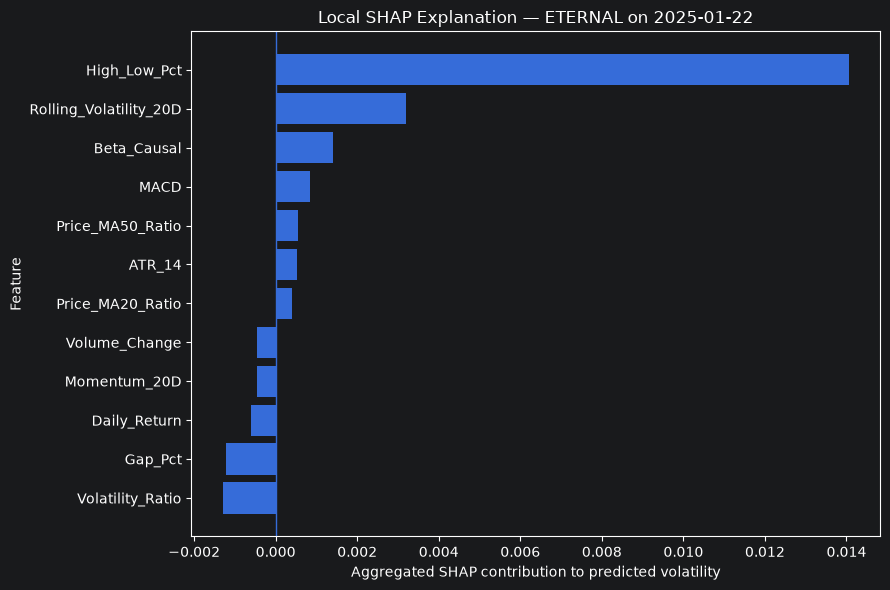

In [16]:
plot_local = local_df.head(12).sort_values("SHAP_Contribution")

plt.figure(figsize=(9, 6))
plt.barh(plot_local["Feature"], plot_local["SHAP_Contribution"])
plt.axvline(0, linewidth=1)
plt.xlabel("Aggregated SHAP contribution to predicted volatility")
plt.ylabel("Feature")
plt.title(f"Local SHAP Explanation — {local_stock} on {local_date.date()}")
plt.tight_layout()
plt.show()

## 12. SHAP heatmap for the selected observation

This shows the signed contribution of each feature over the 60-day history. It helps distinguish whether the forecast is driven by recent or older observations.

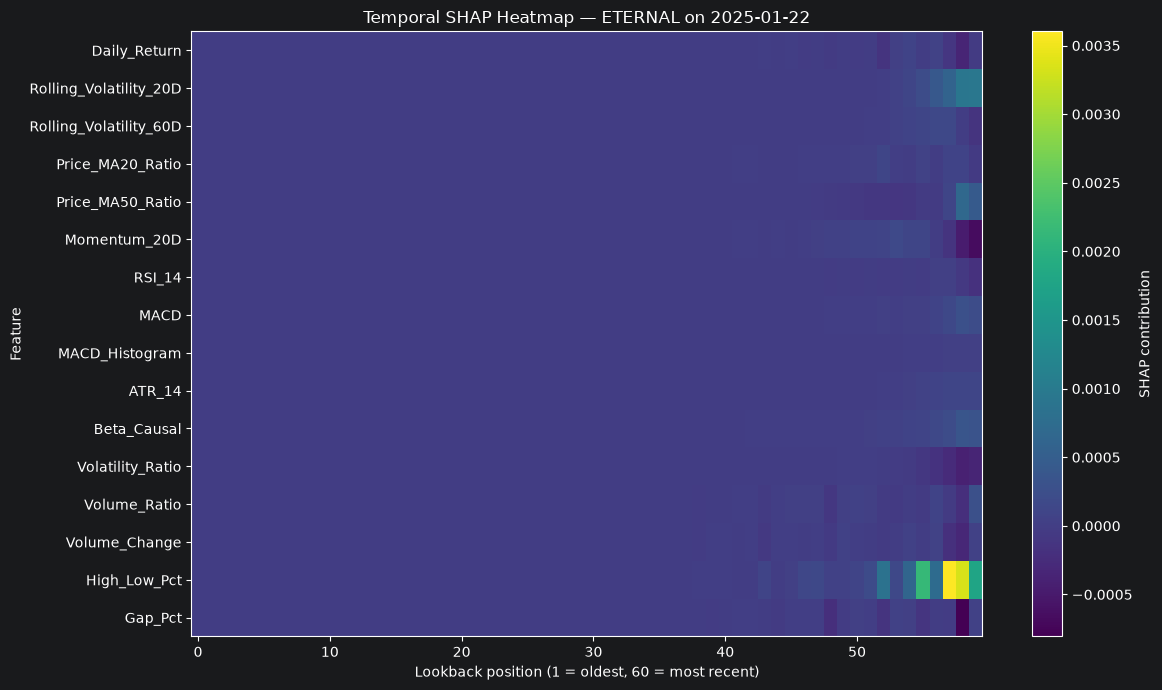

In [17]:
plt.figure(figsize=(12, 7))
plt.imshow(local_shap[0].T, aspect="auto", interpolation="nearest")
plt.colorbar(label="SHAP contribution")
plt.yticks(np.arange(len(LSTM_FEATURES)), LSTM_FEATURES)
plt.xlabel("Lookback position (1 = oldest, 60 = most recent)")
plt.ylabel("Feature")
plt.title(f"Temporal SHAP Heatmap — {local_stock} on {local_date.date()}")
plt.tight_layout()
plt.show()

## 13. SHAP consistency check

For an additive explanation, the sum of SHAP contributions plus the expected/background output should approximately reconstruct the model prediction. GradientExplainer versions can expose expected values differently, so this check is reported as an approximate diagnostic rather than a strict equality assertion.

In [18]:
background_pred = model(background).detach().cpu().numpy().ravel()
background_value = float(background_pred.mean())

local_shap_sum = float(local_shap[0].sum())
reconstructed = background_value + local_shap_sum

print("Mean background prediction:", f"{background_value:.8f}")
print("Sum of local SHAP values:", f"{local_shap_sum:.8f}")
print("Approx. reconstructed prediction:", f"{reconstructed:.8f}")
print("Actual model prediction:", f"{local_pred:.8f}")
print("Approx. reconstruction error:", f"{abs(reconstructed-local_pred):.8f}")

Mean background prediction: 0.01795623
Sum of local SHAP values: 0.01705517
Approx. reconstructed prediction: 0.03501140
Actual model prediction: 0.03443678
Approx. reconstruction error: 0.00057461


## 14. Save SHAP outputs

The saved CSVs can later be used by the QuantRisk AI dashboard for explainability panels.

In [19]:
os.makedirs("models", exist_ok=True)

global_importance.to_csv("models/lstm_shap_global_importance.csv", index=False)
mean_signed.to_csv("models/lstm_shap_mean_signed_contribution.csv", index=False)
local_df.to_csv("models/lstm_shap_local_explanation.csv", index=False)

print("Saved:")
print("- models/lstm_shap_global_importance.csv")
print("- models/lstm_shap_mean_signed_contribution.csv")
print("- models/lstm_shap_local_explanation.csv")

Saved:
- models/lstm_shap_global_importance.csv
- models/lstm_shap_mean_signed_contribution.csv
- models/lstm_shap_local_explanation.csv


## 15. Interview interpretation

### What SHAP tells us
- **Global SHAP:** which engineered features most influence LSTM volatility forecasts on average.
- **Signed SHAP:** whether a feature tends to push the forecast upward or downward in the explained sample.
- **Temporal SHAP:** which parts of the 60-day history receive more influence.
- **Local SHAP:** why one specific stock/date received its particular volatility forecast.

### Important limitation
SHAP describes model attribution; it does **not** prove that a feature causally changes market volatility. Also, correlated financial indicators can share or redistribute attribution.

### Methodology checklist
- [x] Module 5 model loaded; no retraining
- [x] Same 16 features
- [x] Same 60-day lookback
- [x] Same train-fitted imputer and scaler
- [x] Same chronological/purged target construction
- [x] SHAP background sampled only from training sequences
- [x] Test observations used for explanation, not model fitting
- [x] Global, directional, temporal and local explanations included

# Module 6 Enhancement — Robust SHAP Validation & Case Analysis

This section strengthens the existing SHAP analysis without changing the trained LSTM.

It adds:
- model-prediction consistency checking against Module 5 predictions
- genuinely stratified explanation sampling
- SHAP reconstruction/additivity diagnostics
- feature × time-step importance
- representative local cases
- clean CSV and PNG exports
- a final methodology checklist

**Important:** SHAP explains the model output; it does not establish causality.


In [20]:
# 22. Validate the loaded LSTM against the saved Module 5 predictions

with torch.no_grad():
    module5_check_pred = (
        model(torch.from_numpy(Xte).to(device))
        .detach().cpu().numpy().reshape(-1)
    )

module5_predictions_path = "../backend/models/lstm_test_predictions.csv"

if os.path.exists(module5_predictions_path):
    saved_pred = pd.read_csv(module5_predictions_path)

    # Match by Date + Stock when available.
    if {"Date", "Stock", "Predicted_Volatility"}.issubset(saved_pred.columns):
        saved_pred["Date"] = pd.to_datetime(saved_pred["Date"])
        current_meta = meta_te.copy()
        current_meta["Model_Prediction"] = module5_check_pred

        merged = current_meta.merge(
            saved_pred[["Date", "Stock", "Predicted_Volatility"]],
            on=["Date", "Stock"],
            how="inner"
        )

        if len(merged) > 0:
            pred_diff = np.abs(
                merged["Model_Prediction"] - merged["Predicted_Volatility"]
            )
            print("Matched Module 5 predictions:", len(merged))
            print("Max absolute prediction difference:", f"{pred_diff.max():.10f}")
            print("Mean absolute prediction difference:", f"{pred_diff.mean():.10f}")
            assert pred_diff.max() < 1e-5, "Loaded model does not reproduce Module 5 predictions."
            print("Model consistency check: PASS")
        else:
            print("No matching Date + Stock rows found; consistency check skipped.")
    else:
        print("Saved prediction file lacks expected columns; consistency check skipped.")
else:
    print("Module 5 prediction CSV not found; model consistency check skipped.")

Matched Module 5 predictions: 11123
Max absolute prediction difference: 0.0000000045
Mean absolute prediction difference: 0.0000000005
Model consistency check: PASS


In [21]:
# 23. Stratified explanation sample
# Explain observations from low, medium, and high predicted-volatility regions.

explain_meta = meta_te.iloc[explain_idx].copy().reset_index(drop=True)
explain_meta["Actual_Volatility"] = yte[explain_idx]

with torch.no_grad():
    explain_pred = (
        model(X_explain)
        .detach().cpu().numpy().reshape(-1)
    )

explain_meta["Predicted_Volatility"] = explain_pred
explain_meta["Risk_Class"] = np.where(
    explain_meta["Predicted_Volatility"] >= risk_threshold,
    "High Risk",
    "Low Risk"
)

q1, q2 = explain_meta["Predicted_Volatility"].quantile([0.33, 0.67])

low_idx = explain_meta.index[explain_meta["Predicted_Volatility"] <= q1].tolist()
mid_idx = explain_meta.index[
    (explain_meta["Predicted_Volatility"] > q1) &
    (explain_meta["Predicted_Volatility"] <= q2)
].tolist()
high_idx = explain_meta.index[explain_meta["Predicted_Volatility"] > q2].tolist()

print("Explanation cases:", len(explain_meta))
print("Low / Medium / High:", len(low_idx), len(mid_idx), len(high_idx))
print(explain_meta.groupby("Risk_Class").size())


Explanation cases: 100
Low / Medium / High: 33 34 33
Risk_Class
High Risk     8
Low Risk     92
dtype: int64


In [22]:
# 24. SHAP reconstruction diagnostic

# For GradientExplainer, expected_value is not always exposed consistently
# across SHAP versions. Therefore we estimate the background model output
# directly and compare reconstructed predictions.

with torch.no_grad():
    background_pred = (
        model(background).detach().cpu().numpy().reshape(-1)
    )

baseline = float(background_pred.mean())

shap_total = shap_values.reshape(EXPLAIN_SIZE, -1).sum(axis=1)
reconstructed = baseline + shap_total
actual_model_output = explain_pred

reconstruction_error = actual_model_output - reconstructed

shap_check = pd.DataFrame({
    "Model_Prediction": actual_model_output,
    "SHAP_Reconstructed": reconstructed,
    "Reconstruction_Error": reconstruction_error,
    "Abs_Reconstruction_Error": np.abs(reconstruction_error)
})

print(shap_check.describe().round(8))

print(
    "Mean absolute reconstruction error:",
    f"{shap_check['Abs_Reconstruction_Error'].mean():.8f}"
)
print(
    "Max absolute reconstruction error:",
    f"{shap_check['Abs_Reconstruction_Error'].max():.8f}"
)

# GradientExplainer is an approximation, so use this as a diagnostic rather
# than requiring exact equality.


       Model_Prediction  SHAP_Reconstructed  Reconstruction_Error  \
count        100.000000          100.000000            100.000000   
mean           0.015294            0.015320             -0.000026   
std            0.003924            0.003910              0.000345   
min            0.004593            0.005181             -0.000816   
25%            0.012879            0.013109             -0.000226   
50%            0.014760            0.014702             -0.000064   
75%            0.017061            0.017173              0.000184   
max            0.034437            0.034102              0.000922   

       Abs_Reconstruction_Error  
count                100.000000  
mean                   0.000275  
std                    0.000208  
min                    0.000010  
25%                    0.000110  
50%                    0.000211  
75%                    0.000414  
max                    0.000922  
Mean absolute reconstruction error: 0.00027537
Max absolute reconstructi

,Daily_Return,Rolling_Volatility_20D,Rolling_Volatility_60D,Price_MA20_Ratio,Price_MA50_Ratio,Momentum_20D,RSI_14,MACD,MACD_Histogram,ATR_14,Beta_Causal,Volatility_Ratio,Volume_Ratio,Volume_Change,High_Low_Pct,Gap_Pct
Lookback_Position,,,,,,,,,,,,,,,,
1,2.177098e-11,1.051040e-10,4.410518e-11,3.238388e-11,1.252662e-10,6.018326e-11,6.615836e-11,8.106169e-11,1.982031e-11,4.116618e-11,1.687188e-11,6.067620e-11,7.847543e-11,6.456241e-11,2.625090e-10,7.760908e-11
2,4.222748e-11,1.368804e-10,4.891590e-11,5.951799e-11,1.678793e-10,7.070433e-11,6.820602e-11,7.083691e-11,7.346735e-11,1.055054e-10,3.001814e-11,6.357169e-11,1.554260e-10,9.256874e-11,3.829736e-10,1.809446e-10
3,5.270220e-11,1.648427e-10,5.942132e-11,7.878817e-11,2.165679e-10,9.735514e-11,7.897895e-11,1.269054e-10,6.201027e-11,6.121773e-11,4.201952e-11,6.076332e-11,1.907608e-10,1.328085e-10,4.058626e-10,1.587403e-10
4,6.370266e-11,2.129452e-10,6.465535e-11,9.037164e-11,2.919789e-10,1.186790e-10,9.097349e-11,1.416129e-10,7.400034e-11,9.041585e-11,6.273938e-11,6.321892e-11,2.292462e-10,1.957474e-10,6.195272e-10,2.715592e-10
5,7.377702e-11,2.798076e-10,1.008091e-10,1.215987e-10,3.942628e-10,1.605924e-10,1.261448e-10,1.904228e-10,4.588056e-11,1.527854e-10,8.997831e-11,7.997566e-11,3.013529e-10,2.488777e-10,7.206597e-10,2.896791e-10


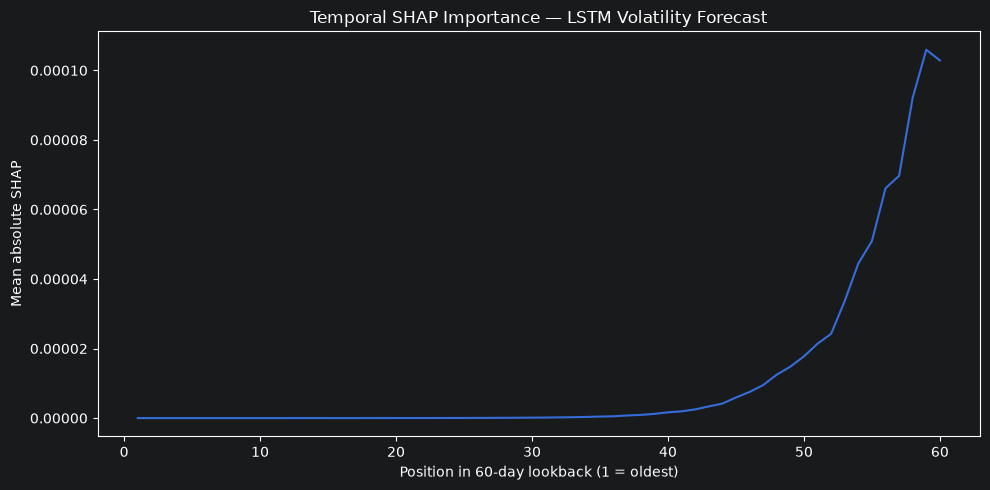

In [23]:
# 25. Feature × time-step importance

feature_time_importance = pd.DataFrame(
    np.mean(np.abs(shap_values), axis=0),
    columns=LSTM_FEATURES
)

feature_time_importance.index = np.arange(1, LOOKBACK + 1)
feature_time_importance.index.name = "Lookback_Position"

display(feature_time_importance.head())

# Overall temporal importance
temporal_importance = pd.DataFrame({
    "Lookback_Position": np.arange(1, LOOKBACK + 1),
    "Mean_Abs_SHAP": np.mean(np.abs(shap_values), axis=(0, 2))
})

plt.figure(figsize=(10, 5))
plt.plot(
    temporal_importance["Lookback_Position"],
    temporal_importance["Mean_Abs_SHAP"]
)
plt.xlabel("Position in 60-day lookback (1 = oldest)")
plt.ylabel("Mean absolute SHAP")
plt.title("Temporal SHAP Importance — LSTM Volatility Forecast")
plt.tight_layout()
plt.show()


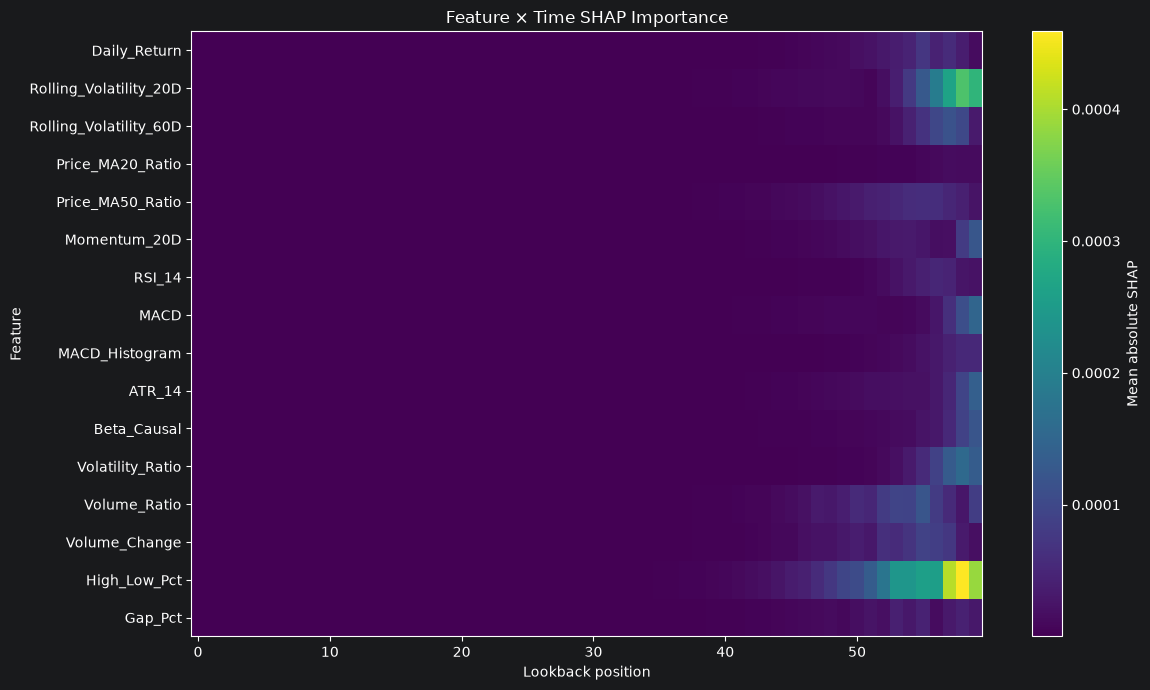

In [24]:
# 26. Feature × time heatmap

plt.figure(figsize=(12, 7))
plt.imshow(
    feature_time_importance.T.values,
    aspect="auto",
    interpolation="nearest"
)
plt.colorbar(label="Mean absolute SHAP")
plt.yticks(np.arange(len(LSTM_FEATURES)), LSTM_FEATURES)
plt.xlabel("Lookback position")
plt.ylabel("Feature")
plt.title("Feature × Time SHAP Importance")
plt.tight_layout()
plt.show()


In [25]:
# 27. Representative local cases

# Reuse the calculated explanation predictions to identify:
# 1) highest predicted volatility
# 2) lowest predicted volatility
# 3) largest absolute prediction error
# 4) closest-to-threshold prediction

explain_meta["Abs_Error"] = np.abs(
    explain_meta["Actual_Volatility"] -
    explain_meta["Predicted_Volatility"]
)

case_positions = {
    "Highest predicted volatility": int(
        explain_meta["Predicted_Volatility"].idxmax()
    ),
    "Lowest predicted volatility": int(
        explain_meta["Predicted_Volatility"].idxmin()
    ),
    "Largest prediction error": int(
        explain_meta["Abs_Error"].idxmax()
    ),
    "Closest to risk threshold": int(
        (explain_meta["Predicted_Volatility"] - risk_threshold).abs().idxmin()
    )
}

case_rows = []
for case_name, pos in case_positions.items():
    case_rows.append({
        "Case": case_name,
        "Date": explain_meta.loc[pos, "Date"],
        "Stock": explain_meta.loc[pos, "Stock"],
        "Actual_Volatility": explain_meta.loc[pos, "Actual_Volatility"],
        "Predicted_Volatility": explain_meta.loc[pos, "Predicted_Volatility"],
        "Risk_Threshold": risk_threshold,
        "Risk_Class": explain_meta.loc[pos, "Risk_Class"],
        "Absolute_Error": explain_meta.loc[pos, "Abs_Error"]
    })

representative_cases = pd.DataFrame(case_rows)
display(representative_cases)


,Case,Date,Stock,Actual_Volatility,Predicted_Volatility,Risk_Threshold,Risk_Class,Absolute_Error
0,Highest predicted volatility,2025-01-22,ETERNAL,0.034338,0.034437,0.021286,High Risk,0.000099
1,Lowest predicted volatility,2025-11-12,MARUTI,0.009648,0.004593,0.021286,Low Risk,0.005055
2,Largest prediction error,2025-03-06,INDUSINDBK,0.067131,0.016624,0.021286,Low Risk,0.050507
3,Closest to risk threshold,2025-02-10,BEL,0.025368,0.021291,0.021286,High Risk,0.004077


In [26]:
# 28. Local SHAP contributions for representative cases

local_rows = []

for case_name, pos in case_positions.items():
    local_shap = shap_values[pos].sum(axis=0)

    for feature, contribution in zip(LSTM_FEATURES, local_shap):
        local_rows.append({
            "Case": case_name,
            "Date": explain_meta.loc[pos, "Date"],
            "Stock": explain_meta.loc[pos, "Stock"],
            "Feature": feature,
            "SHAP_Contribution": contribution,
            "Abs_SHAP_Contribution": abs(contribution)
        })

local_case_shap = pd.DataFrame(local_rows)

for case_name in case_positions:
    display(
        local_case_shap[local_case_shap["Case"] == case_name]
        .sort_values("Abs_SHAP_Contribution", ascending=False)
        .head(10)
    )


,Case,Date,Stock,Feature,SHAP_Contribution,Abs_SHAP_Contribution
14,Highest predicted volatility,2025-01-22,ETERNAL,High_Low_Pct,0.013363,0.013363
1,Highest predicted volatility,2025-01-22,ETERNAL,Rolling_Volatility_20D,0.002818,0.002818
10,Highest predicted volatility,2025-01-22,ETERNAL,Beta_Causal,0.001599,0.001599
11,Highest predicted volatility,2025-01-22,ETERNAL,Volatility_Ratio,-0.001281,0.001281
15,Highest predicted volatility,2025-01-22,ETERNAL,Gap_Pct,-0.001201,0.001201
7,Highest predicted volatility,2025-01-22,ETERNAL,MACD,0.000708,0.000708
0,Highest predicted volatility,2025-01-22,ETERNAL,Daily_Return,-0.000587,0.000587
4,Highest predicted volatility,2025-01-22,ETERNAL,Price_MA50_Ratio,0.000563,0.000563
13,Highest predicted volatility,2025-01-22,ETERNAL,Volume_Change,-0.000467,0.000467
9,Highest predicted volatility,2025-01-22,ETERNAL,ATR_14,0.000461,0.000461


,Case,Date,Stock,Feature,SHAP_Contribution,Abs_SHAP_Contribution
24,Lowest predicted volatility,2025-11-12,MARUTI,MACD_Histogram,-0.005851,0.005851
30,Lowest predicted volatility,2025-11-12,MARUTI,High_Low_Pct,-0.002294,0.002294
25,Lowest predicted volatility,2025-11-12,MARUTI,ATR_14,-0.002077,0.002077
17,Lowest predicted volatility,2025-11-12,MARUTI,Rolling_Volatility_20D,-0.002066,0.002066
27,Lowest predicted volatility,2025-11-12,MARUTI,Volatility_Ratio,0.000675,0.000675
28,Lowest predicted volatility,2025-11-12,MARUTI,Volume_Ratio,-0.000532,0.000532
20,Lowest predicted volatility,2025-11-12,MARUTI,Price_MA50_Ratio,-0.000369,0.000369
18,Lowest predicted volatility,2025-11-12,MARUTI,Rolling_Volatility_60D,-0.000357,0.000357
22,Lowest predicted volatility,2025-11-12,MARUTI,RSI_14,0.000211,0.000211
31,Lowest predicted volatility,2025-11-12,MARUTI,Gap_Pct,0.000206,0.000206


,Case,Date,Stock,Feature,SHAP_Contribution,Abs_SHAP_Contribution
44,Largest prediction error,2025-03-06,INDUSINDBK,Volume_Ratio,-0.002439,0.002439
46,Largest prediction error,2025-03-06,INDUSINDBK,High_Low_Pct,0.001185,0.001185
42,Largest prediction error,2025-03-06,INDUSINDBK,Beta_Causal,0.001008,0.001008
45,Largest prediction error,2025-03-06,INDUSINDBK,Volume_Change,-0.000693,0.000693
37,Largest prediction error,2025-03-06,INDUSINDBK,Momentum_20D,-0.000601,0.000601
32,Largest prediction error,2025-03-06,INDUSINDBK,Daily_Return,-0.000387,0.000387
43,Largest prediction error,2025-03-06,INDUSINDBK,Volatility_Ratio,-0.000353,0.000353
40,Largest prediction error,2025-03-06,INDUSINDBK,MACD_Histogram,0.000238,0.000238
38,Largest prediction error,2025-03-06,INDUSINDBK,RSI_14,0.000183,0.000183
33,Largest prediction error,2025-03-06,INDUSINDBK,Rolling_Volatility_20D,0.000148,0.000148


,Case,Date,Stock,Feature,SHAP_Contribution,Abs_SHAP_Contribution
62,Closest to risk threshold,2025-02-10,BEL,High_Low_Pct,0.002922,0.002922
49,Closest to risk threshold,2025-02-10,BEL,Rolling_Volatility_20D,0.002824,0.002824
59,Closest to risk threshold,2025-02-10,BEL,Volatility_Ratio,-0.001750,0.001750
60,Closest to risk threshold,2025-02-10,BEL,Volume_Ratio,-0.001211,0.001211
63,Closest to risk threshold,2025-02-10,BEL,Gap_Pct,-0.000585,0.000585
50,Closest to risk threshold,2025-02-10,BEL,Rolling_Volatility_60D,0.000491,0.000491
53,Closest to risk threshold,2025-02-10,BEL,Momentum_20D,0.000455,0.000455
52,Closest to risk threshold,2025-02-10,BEL,Price_MA50_Ratio,-0.000440,0.000440
57,Closest to risk threshold,2025-02-10,BEL,ATR_14,0.000336,0.000336
55,Closest to risk threshold,2025-02-10,BEL,MACD,0.000177,0.000177


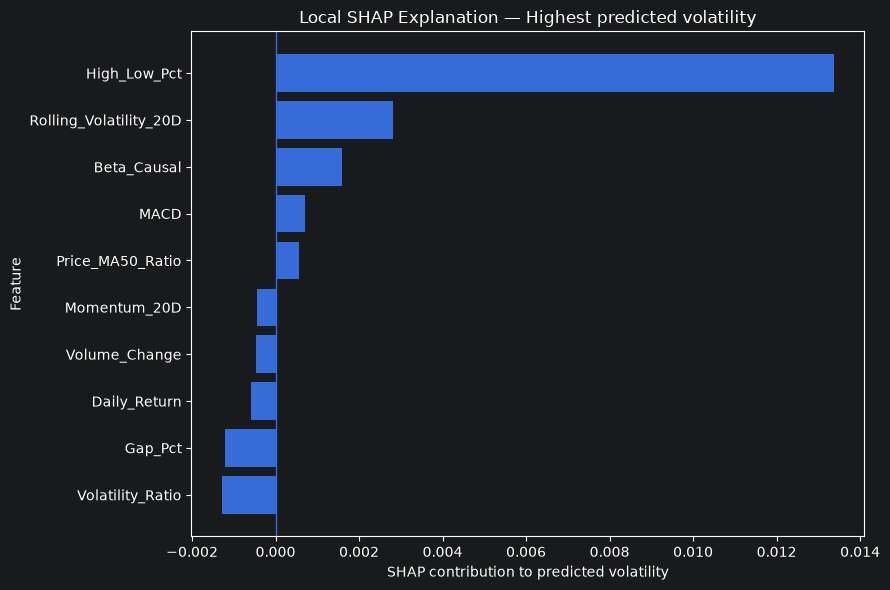

In [27]:
# 29. Plot the strongest local explanation

case_name = "Highest predicted volatility"
case_data = (
    local_case_shap[local_case_shap["Case"] == case_name]
    .sort_values("SHAP_Contribution")
)

top_local = pd.concat([
    case_data.head(5),
    case_data.tail(5)
]).drop_duplicates().sort_values("SHAP_Contribution")

plt.figure(figsize=(9, 6))
plt.barh(top_local["Feature"], top_local["SHAP_Contribution"])
plt.axvline(0, linewidth=1)
plt.xlabel("SHAP contribution to predicted volatility")
plt.ylabel("Feature")
plt.title(f"Local SHAP Explanation — {case_name}")
plt.tight_layout()
plt.show()


In [29]:
# 30. Clean exports

os.makedirs("../backend/models/shap", exist_ok=True)

global_importance.to_csv(
    "../backend/models/shap/lstm_shap_global_importance.csv",
    index=False
)

# Existing signed contribution table
signed_contribution = pd.DataFrame({
    "Feature": LSTM_FEATURES,
    "Mean_Signed_SHAP": np.mean(shap_values, axis=(0, 1))
}).sort_values("Mean_Signed_SHAP")

signed_contribution.to_csv(
    "../backend/models/shap/lstm_shap_mean_signed_contribution.csv",
    index=False
)

feature_time_importance.to_csv(
    "../backend/models/shap/lstm_shap_feature_time_importance.csv"
)

representative_cases.to_csv(
    "../backend/models/shap/lstm_shap_representative_cases.csv",
    index=False
)

local_case_shap.to_csv(
    "../backend/models/shap/lstm_shap_local_cases.csv",
    index=False
)

shap_check.to_csv(
    "../backend/models/shap/lstm_shap_reconstruction_check.csv",
    index=False
)

np.save(
    "../backend/models/shap/lstm_shap_values.npy",
    shap_values
)

print("SHAP artifacts exported to ../backend/models/shap/")

SHAP artifacts exported to ../backend/models/shap/


## 31. Final Module 6 checklist

- [x] Saved Module 5 LSTM reused
- [x] Module 5 preprocessing reused
- [x] No model retraining
- [x] Test sequences reconstructed consistently
- [x] Training-only SHAP background
- [x] SHAP calculated at time-step × feature level
- [x] Global mean absolute SHAP
- [x] Signed SHAP contribution
- [x] Temporal importance
- [x] Feature × time importance
- [x] Representative local cases
- [x] SHAP reconstruction diagnostic
- [x] Clean CSV/NPY exports
- [x] SHAP interpreted as model explanation, not causal inference

### Recommended interpretation

SHAP should be reported as **model attribution**. A high SHAP value means the model's prediction was sensitive to that input relative to the selected background distribution; it does not prove that the feature causes future volatility.

For the final QuantRisk AI report, combine:
1. Module 5 predictive performance,
2. Module 6 global SHAP importance,
3. temporal SHAP analysis,
4. local case explanations.

This provides both **forecasting performance** and **model interpretability**.
